# Truncation pipelines 

Suppressing exponential branching during Heisenberg propagation is primarily done through the use of two main strategies: merging duplicate terms (lossless) and truncating redundant terms (lossy). propaq merges for you — the engine folds duplicates as terms are inserted, with no cadence to tune — so what you control is the truncation, including custom schemes of your own (see plugins/ for examples). In this notebook, we'll explore how to combine different truncation schemes to achieve a balance between accuracy and runtime.

## Setup 

We'll build a simple system that we can experiment with, the same H2 molecule from the previous notebook. We'll use the same UCJ ansatz, but this time we'll focus on how to control the propagation of the circuit through different truncation schemes.

In [2]:
import ffsim
import matplotlib.pyplot as plt; plt.rcParams.update({"font.family": "serif", "font.size": 12})
import numpy as np
import pyscf
import pyscf.cc
import numpy as np
import pyscf.mcscf
import qiskit
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.providers.fake_provider import GenericBackendV2

atom: str = "H"
natoms: int = 2
nlayers: int = 1

def generate_linear_geometry(atom: str, natoms: int, atomic_distance: float = 1.0) -> str:
    """Returns a linear Hydrogen chain geometry for use in PySCF molecule construction.

    Args:
        natoms: Number of Hydrogen atoms in the chain.
        atomic_distance: Equal spacing between Hydrogen atoms.
    """
    return "; ".join([f"{atom} 0 0 {i * atomic_distance}" for i in range(natoms)])

# Specify molecule properties
spin_sq = 0

# Build molecule
mol = pyscf.gto.Mole()
mol.build(
    atom=generate_linear_geometry(atom, natoms),
    basis="sto-6g",
)

# Define active space
n_frozen = 0
active_space = range(n_frozen, mol.nao_nr())

# Get molecular integrals
scf = pyscf.scf.RHF(mol).run()
norb = len(active_space)
n_electrons = int(sum(scf.mo_occ[active_space]))
n_alpha = (n_electrons + mol.spin) // 2
n_beta = (n_electrons - mol.spin) // 2
nelec = (n_alpha, n_beta)
cas = pyscf.mcscf.CASCI(scf, norb, nelec)
mo = cas.sort_mo(active_space, base=0)
hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), norb)

print(f"norb = {norb}")
print(f"nelec = {nelec}")

# Get CCSD t2 amplitudes for initializing the ansatz
ccsd = pyscf.cc.CCSD(
    scf, frozen=[i for i in range(mol.nao_nr()) if i not in active_space]
).run()
t1 = ccsd.t1
t2 = ccsd.t2

ccsd_energy = ccsd.e_tot

import warnings

from qiskit.transpiler import CouplingMap

warnings.formatwarning = lambda msg, *args, **kwargs: f"Warning: {msg}\n"

# Set ansatz properties
n_reps = nlayers

# Initialize backend, use exactly 2*norb qubits so transpilation adds no ancilla
# qubits and physical qubit indices match the molecular spin-orbital ordering.
coupling_map = CouplingMap.from_full(2 * norb, bidirectional=True)
backend = GenericBackendV2(
    2 * norb,
    coupling_map=coupling_map,
    basis_gates=["cp", "xx_plus_yy", "p", "x", "swap"],
)

# Create the LUCJ ansatz operator
ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
    t2=t2,
    t1=t1,
    n_reps=n_reps,
    # Setting optimize=True enables the "compressed" factorization
    optimize=True,
    options=dict(maxiter=10_000),
)

# create an empty quantum circuit
qubits = QuantumRegister(2 * norb, name="q")
circuit = QuantumCircuit(qubits)

# prepare Hartree-Fock state as the reference state and append it to the quantum circuit
circuit.append(ffsim.qiskit.PrepareHartreeFockJW(norb, nelec), qubits)

# apply the UCJ operator to the reference state
circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)


compiled = qiskit.transpile(
    circuit, backend=backend, optimization_level=3,
    initial_layout=list(range(2 * norb)),
)

print(f"Number of qubits: {compiled.num_qubits}")
print(f"Gate counts: {compiled.count_ops()}")

compiled.draw(fold=-1)

converged SCF energy = -1.07358293078636
norb = 2
nelec = (1, 1)
E(CCSD) = -1.108873060181063  E_corr = -0.03529012939470301
Number of qubits: 4
Gate counts: OrderedDict({'p': 8, 'cp': 6, 'xx_plus_yy': 4, 'x': 2})


┌───┐┌────────────────────┐┌────────────┐                                                                   ┌─────────────────────┐  ┌──────┐ 
q_0 -> 0 ┤ X ├┤1                   ├┤ P(-3.2162) ├─■────────────■───────────────────────────■────────────────────────┤1                    ├──┤ P(π) ├─
         └───┘│  (XX+YY)(π/2,-π/4) │├────────────┤ │P(0.20886)  │                           │                        │  (XX+YY)(π/2,-3π/2) │┌─┴──────┴┐
q_1 -> 1 ─────┤0                   ├┤ P(-2.4308) ├─■────────────┼─────────────■─────────────┼────────────■───────────┤0                    ├┤ P(3π/4) ├
         ┌───┐├────────────────────┤├────────────┤              │P(-0.14919)  │             │            │P(0.20886) ├─────────────────────┤└─┬──────┬┘
q_2 -> 2 ┤ X ├┤1                   ├┤ P(-3.2162) ├─■────────────■─────────────┼─────────────┼────────────■───────────┤1                    ├──┤ P(π) ├─
         └───┘│  (XX+YY)(π/2,-π/4) │├────────────┤ │P(0.20886)                │P(-0.14919)  │P(0.20886)              │  (XX+YY)(π/2,-3π/2) │┌─┴──────┴┐
q_3 -> 3 ─────┤0                   ├┤ P(-2.4308) ├─■──────────────────────────■─────────────■────────────────────────┤0                    ├┤ P(3π/4) ├
              └────────────────────┘└────────────┘                                                                   └─────────────────────┘└─────────┘

In [3]:
from qiskit_nature.second_q.hamiltonians import ElectronicEnergy
from qiskit_nature.second_q.operators import ElectronicIntegrals
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.quantum_info import SparsePauliOp

h2e_phys = np.einsum("prqs->pqrs", eri)  # chemist -> physicist notation
elec_ints = ElectronicIntegrals.from_raw_integrals(hcore, h2e_phys)
elec_hamiltonian = ElectronicEnergy(elec_ints)
mapper = JordanWignerMapper()
hamiltonian = mapper.map(elec_hamiltonian.second_q_op())
hamiltonian = (hamiltonian + SparsePauliOp("I" * (2 * norb), coeffs=[nuclear_repulsion_energy])).simplify()
sorted_indices = np.argsort(-np.abs(hamiltonian.coeffs))
hamiltonian = hamiltonian[sorted_indices]
print(f"Hamiltonian has {len(hamiltonian)} Pauli terms.")

Hamiltonian has 15 Pauli terms.


## Truncation Pipelines

propaq also supports the ability to define composable truncation pipelines. The two most common truncation schemes are by coefficient magnitude and by weight. Terms with small coefficients can be truncated with minimal impact on accuracy, and terms with large weight are unlikely to contribute significantly to the expectation value of the observable.

We'll set a coefficient cutoff of $10^{-10}$, and a weight cutoff of 4. The `TermBudget` specifies how many terms we would like to maintain throughout the simulation, dependent on our memory resources.

In [ ]:
from propaq.circuits import PauliCircuit
from propaq.datatypes import PauliTermSum
from propaq.propagators import PauliPropagator
from propaq.truncation import CoefficientTruncator, TermBudget, WeightTruncator

truncator = [
        CoefficientTruncator(coefficient=1e-10),
        WeightTruncator(weight=4),
        TermBudget(min_terms=10, max_terms=1_000),
]

obs_ham = PauliTermSum.from_sparse_pauli_op(hamiltonian)
pc = PauliCircuit.from_qiskit(compiled.copy())

prop_pauli = PauliPropagator(
        truncation=truncator,
        n_threads=16,
        progress_bar=True,
)

Propagating through gates: 100%|██████████| 44/44 [00:00<00:00, 273.21it/s, terms=50]  


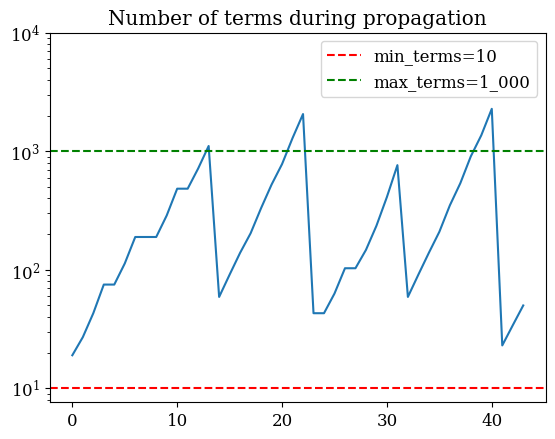

In [27]:
result_pauli = prop_pauli.expectation_value(obs_ham, pc)

plt.plot(result_pauli.n_terms)
plt.axhline(y=10, color="r", linestyle="--", label="min_terms=10")
plt.axhline(y=1_000, color="g", linestyle="--", label="max_terms=1_000")
plt.yscale("log")
plt.ylim(0, 10_000)
plt.legend(loc='best')
plt.title("Number of terms during propagation")
plt.show()

Propagators also accept custom truncation policies, either in Python, Rust, C or AOT-Julia! See the plugins/ directory in examples/and documentation for more information on how to implement custom truncation schemes and noise models.